In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf

In [85]:
#Инициализация датасета
df = pd.read_csv('titanic.csv')

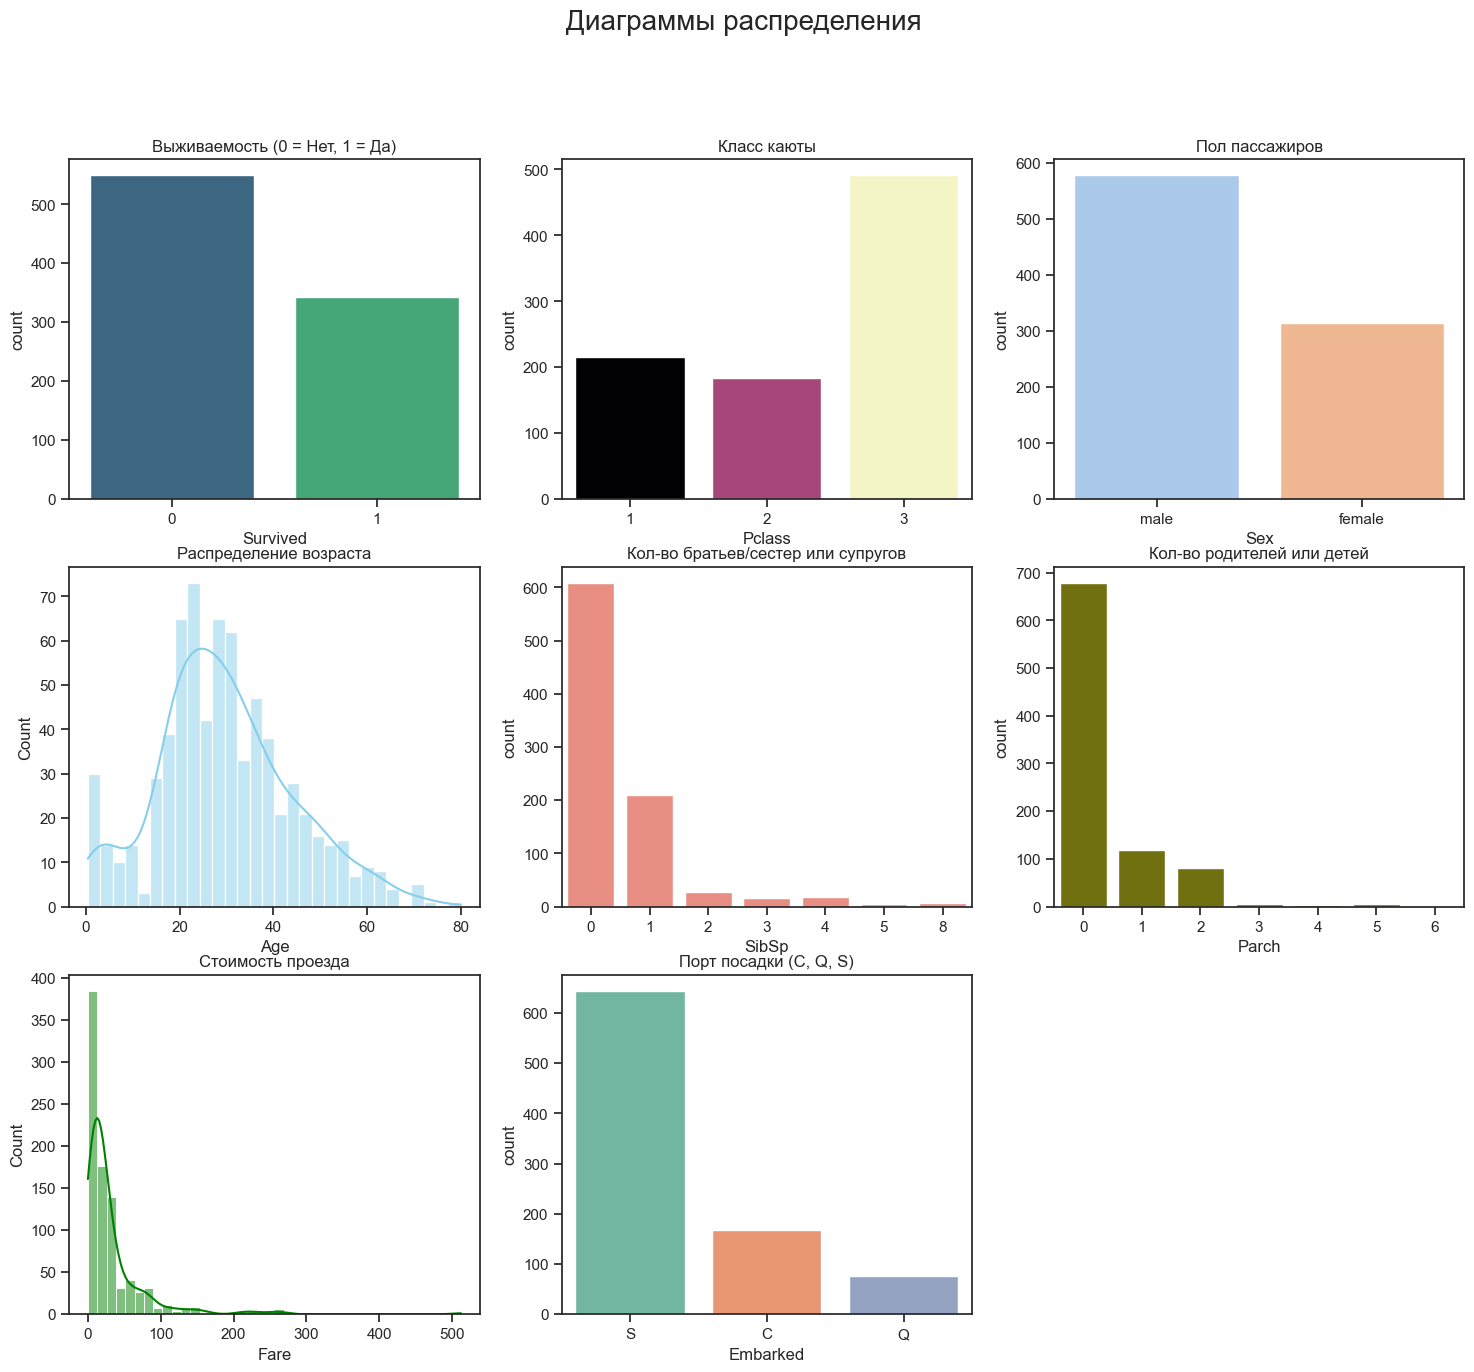

In [86]:
# 1.2.1

# Настройка общей сетки графиков с помощью Matplotlib
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
fig.suptitle('Диаграммы распределения', fontsize=20)

# 1. Survived (Целевой признак)
sns.countplot(x='Survived', hue='Survived', data=df, ax=axes[0, 0], palette='viridis', legend=False)
axes[0, 0].set_title('Выживаемость (0 = Нет, 1 = Да)')

# 2. Pclass (Класс билета)
sns.countplot(x='Pclass', hue='Pclass', data=df, ax=axes[0, 1], palette='magma', legend=False)
axes[0, 1].set_title('Класс каюты')

# 3. Sex (Пол)
sns.countplot(x='Sex', hue='Sex', data=df, ax=axes[0, 2], palette='pastel', legend=False)
axes[0, 2].set_title('Пол пассажиров')

# 4. Age (Возраст)
sns.histplot(df['Age'].dropna(), bins=30, kde=True, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Распределение возраста')

# 5. SibSp (Семья: братья/сестры, супруги)
sns.countplot(x='SibSp', data=df, ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Кол-во братьев/сестер или супругов')

# 6. Parch (Семья: родители/дети)
sns.countplot(x='Parch', data=df, ax=axes[1, 2], color='olive')
axes[1, 2].set_title('Кол-во родителей или детей')

# 7. Fare (Стоимость билета)
sns.histplot(df['Fare'], bins=40, kde=True, ax=axes[2, 0], color='green')
axes[2, 0].set_title('Стоимость проезда')

# 8. Embarked (Порт посадки)
sns.countplot(x='Embarked', hue='Embarked', data=df, ax=axes[2, 1], palette='Set2', legend=False)
axes[2, 1].set_title('Порт посадки (C, Q, S)')

# Удаляем пустой нижний правый график, если он не нужен
fig.delaxes(axes[2, 2])

# Указываем путь и настройки качества
plt.savefig('titanic_plots.png', dpi=300, bbox_inches='tight')

plt.show()

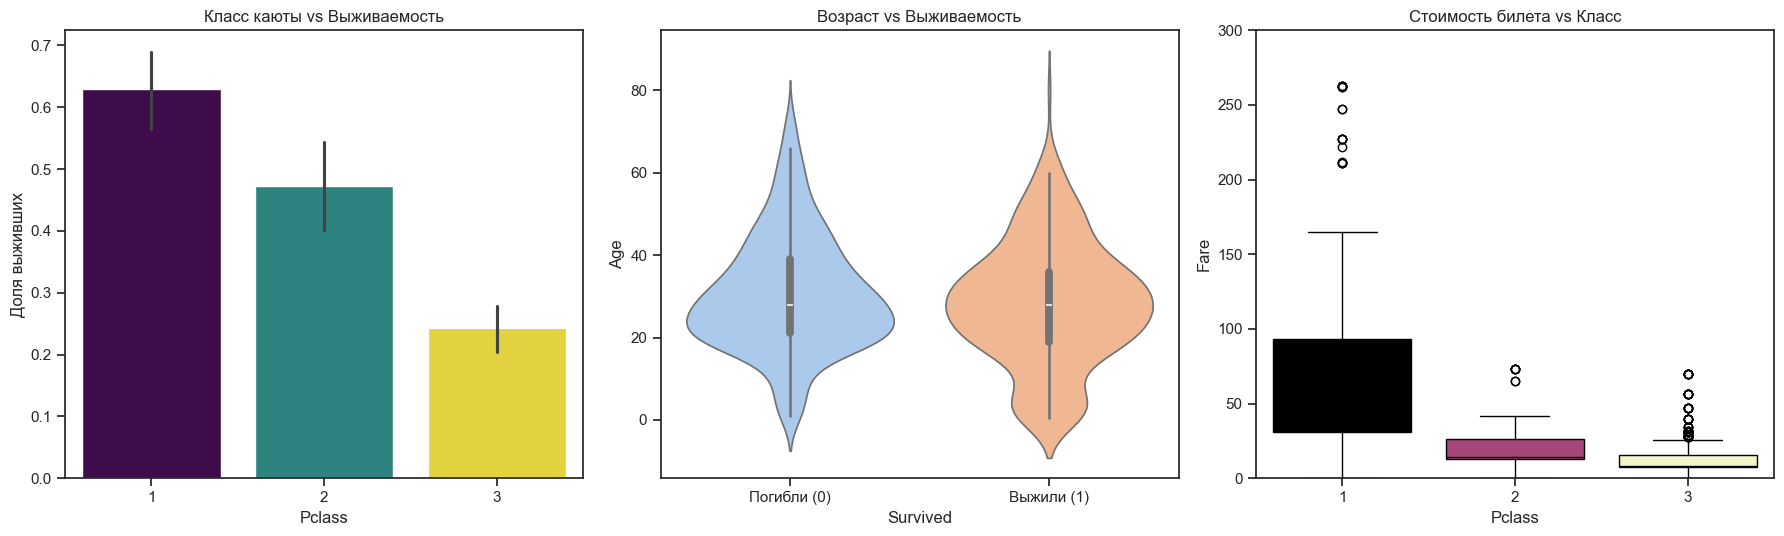

In [87]:
# 1.2.2

sns.set_theme(style="ticks")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Pclass vs Survived (Влияние класса на выживаемость)
sns.barplot(x='Pclass', y='Survived', hue='Pclass', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Класс каюты vs Выживаемость')
axes[0].set_ylabel('Доля выживших')
if axes[0].get_legend(): axes[0].get_legend().remove()

# 2. Age vs Survived (Распределение возраста среди выживших и погибших)
sns.violinplot(x='Survived', y='Age', hue='Survived', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Возраст vs Выживаемость')
# ИСПРАВЛЕНИЕ ОШИБКИ: сначала устанавливаем позиции тиков, потом подписи
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Погибли (0)', 'Выжили (1)'])
if axes[1].get_legend(): axes[1].get_legend().remove()

# 3. Fare vs Pclass (Связь стоимости билета и класса)
sns.boxplot(x='Pclass', y='Fare', hue='Pclass', data=df, ax=axes[2], palette='magma')
axes[2].set_title('Стоимость билета vs Класс')
axes[2].set_ylim(0, 300) # Ограничение для наглядности (убираем экстремальные выбросы)
if axes[2].get_legend(): axes[2].get_legend().remove()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# СОХРАНЕНИЕ: вызываем до plt.show()
plt.savefig('titanic_pairs_analysis.png', dpi=300, bbox_inches='tight')

# Показ графика
plt.show()

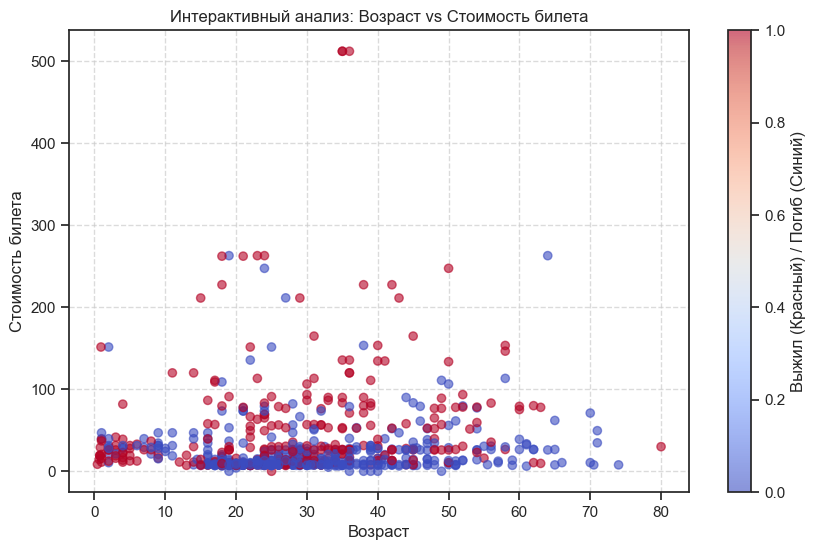

In [88]:
# 1.2.3
# Создаем интерактивную диаграмму рассеяния (Возраст vs Стоимость билета)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['Age'], df['Fare'], c=df['Survived'], cmap='coolwarm', alpha=0.6)

plt.title('Интерактивный анализ: Возраст vs Стоимость билета')
plt.xlabel('Возраст')
plt.ylabel('Стоимость билета')
plt.colorbar(scatter, label='Выжил (Красный) / Погиб (Синий)')
plt.grid(True, linestyle='--', alpha=0.7)

# СОХРАНЕНИЕ: вызываем до plt.show()
plt.savefig('titanic_pairs_analysis_another.png', dpi=300, bbox_inches='tight')

plt.show()

In [89]:
#1.2.4

# Проверяем наличие пропусков
print(df.isnull().any())

# Пропуски в Cabin
qneCabin = df["Cabin"].dropna().unique()

mask = df["Cabin"].isna()

df.loc[mask, "Cabin"] = np.resize(qneCabin, mask.sum())


# Пропуски в Age
median_age = df["Age"].median()

df["Age"] = df["Age"].fillna(median_age)


# Пропуски в Embarked
most_common_port = df["Embarked"].mode()[0]

df["Embarked"] = df["Embarked"].fillna(most_common_port)

# Проверка после обработки
print("\nПропуски после обработки:")
print(df.isnull().sum())


PassengerId    False
Survived       False
Pclass         False
Name           False
Sex            False
Age             True
SibSp          False
Parch          False
Ticket         False
Fare           False
Cabin           True
Embarked        True
dtype: bool

Пропуски после обработки:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


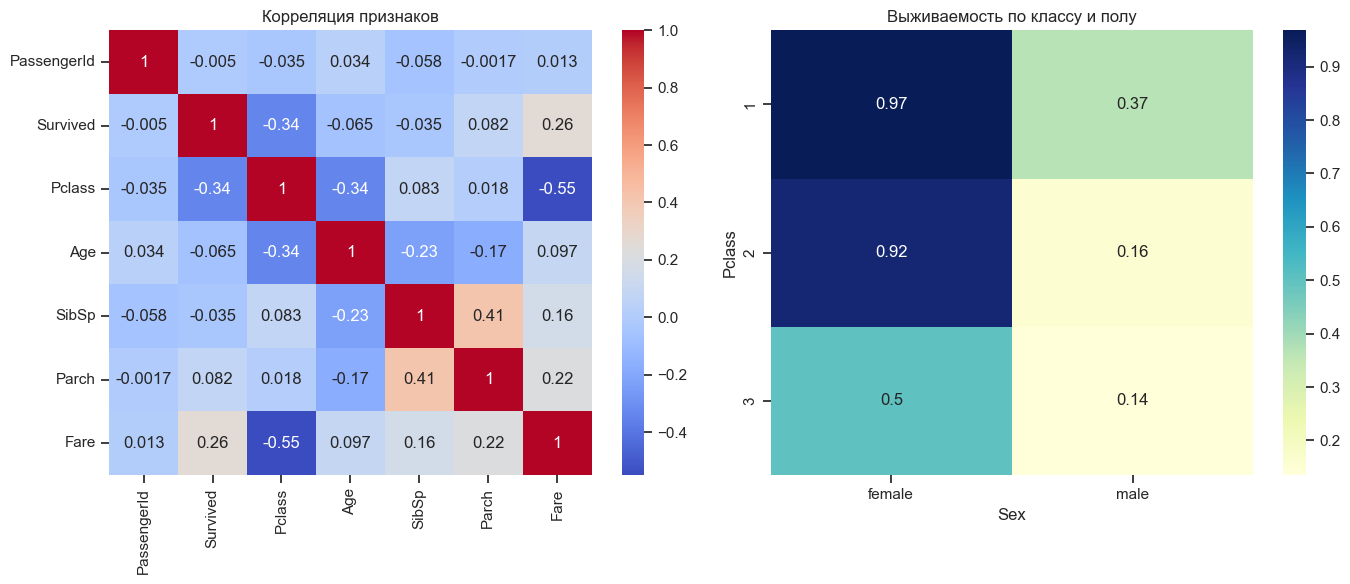

In [90]:
# 1.2.5
# 1. Корреляция числовых признаков
corr = df.corr(numeric_only=True)

# 2. Сводная таблица выживаемости
pivot = df.pivot_table(index='Pclass', columns='Sex', values='Survived', aggfunc='mean')

# Создаем фигуру с двумя картами
fig, ax = plt.subplots(1, 2, figsize=(14,6))

# Первая тепловая карта
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=ax[0])
ax[0].set_title('Корреляция признаков')

# Вторая тепловая карта
sns.heatmap(pivot, annot=True, cmap='YlGnBu', ax=ax[1])
ax[1].set_title('Выживаемость по классу и полу')

plt.savefig('titanic_analysis_priznak.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

In [91]:
#1.2.6

print(df.duplicated().sum())



0


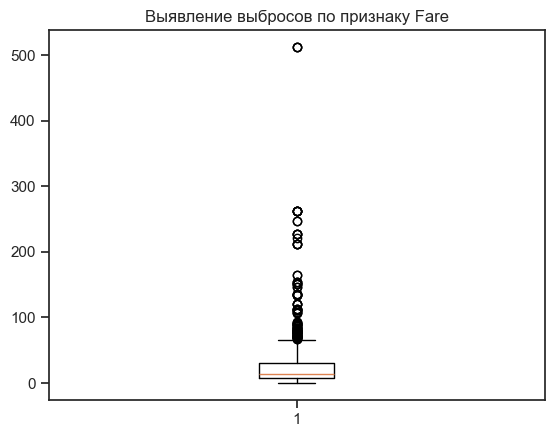

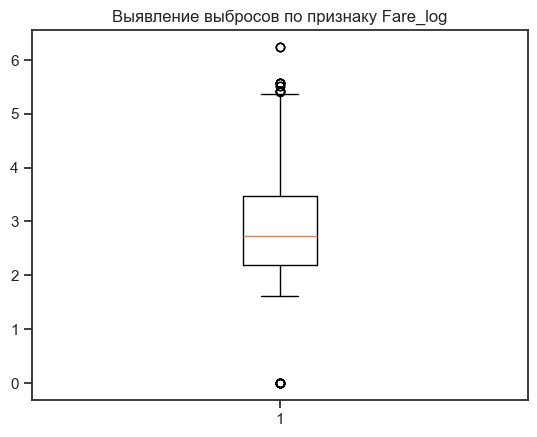

In [92]:
#1.2.7.

plt.boxplot(df["Fare"])
plt.title("Выявление выбросов по признаку Fare")
plt.savefig('beforeAcceptLog.png', dpi=300, bbox_inches='tight')
plt.show()

df["Fare_log"] = np.log1p(df["Fare"])

plt.boxplot(df["Fare_log"])
plt.title("Выявление выбросов по признаку Fare_log")
plt.savefig('AfterAcceptLog.png', dpi=300, bbox_inches='tight')
plt.show()

In [93]:
# 1.2.8.
df.head()

#Выживишие женщины
survivedFemale = df[(df["Survived"] == 1) & (df["Sex"] == "female")]
survivedFemale.head()

#Выжвшие дети младше 12 лет
survivedChildren = df[(df["Survived"] == 1) & (df["Age"] < 12)]
survivedChildren.head()

#Пассажири с высокми тарифами
highFareSurvd = df[(df["Survived"] == 1) & (df["Fare_log"] > 4)]
highFareSurvd.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Fare_log
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,4.280593
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,28.0,1,0,PC 17569,146.5208,B78,C,4.993969
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C,4.353231
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0000,B28,S,4.394449
74,75,1,3,"Bing, Mr. Lee",male,32.0,0,0,1601,56.4958,C7,S,4.051712


In [94]:
# 1.2.9.

np.random.seed(42)

#Коэффициент для уменьшения шума
k = 0.02

sigma_fare = df["Fare"].std() * k
sigma_age = df["Age"].std() * k

df["Fare_log_noisy"] = df["Fare_log"] * (1 + np.random.normal(0, sigma_fare, size=df.shape[0]))
df['Fare_log_noisy'] = np.clip(df['Fare_log_noisy'], 0, None)
df["Age_noisy"] = df["Age"] * (1 + np.random.normal(0, sigma_age, size=df.shape[0]))

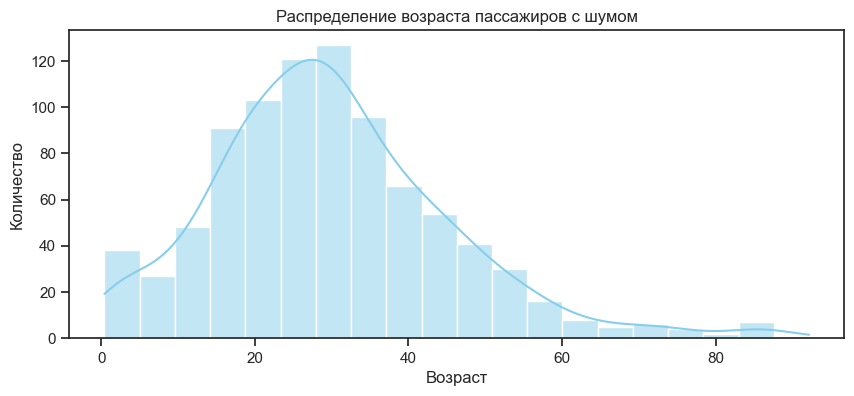

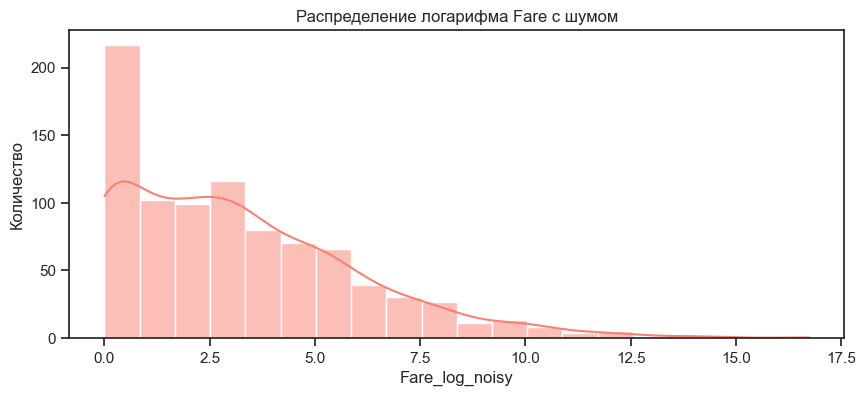

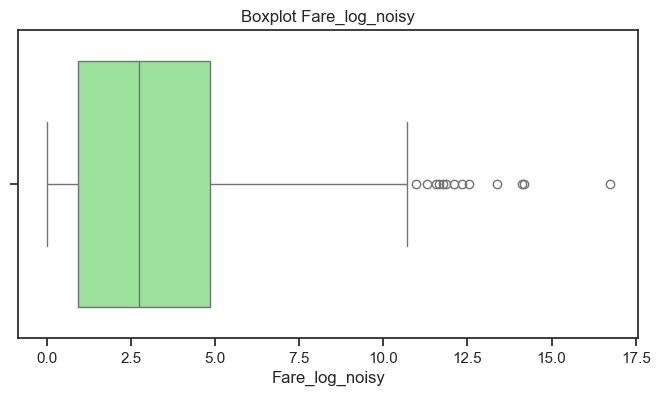

In [ ]:
#1.2.10.

# 1) Распределение возраста
plt.figure(figsize=(10,4))
sns.histplot(df['Age_noisy'], bins=20, kde=True, color='skyblue')
plt.title("Распределение возраста пассажиров с шумом")
plt.xlabel("Возраст")
plt.ylabel("Количество")
plt.savefig('age_noisy_hist.png', dpi=300, bbox_inches='tight')
plt.show()

# 2) Распределение платы за билет (с шумом)
plt.figure(figsize=(10,4))
sns.histplot(df['Fare_log_noisy'], bins=20, kde=True, color='salmon')
plt.title("Распределение логарифма Fare с шумом")
plt.xlabel("Fare_log_noisy")
plt.ylabel("Количество")
plt.savefig('age_noisy_hist_two.png', dpi=300, bbox_inches='tight')
plt.show()
